In [1]:
import pandas as pd

# Load data
data = pd.read_csv('../data/Hospital_Inpatient_Discharges__SPARCS_De-Identified___2022_20250423.csv')
data.head()

/var/folders/s1/z7p70y8n35lcdk9lq0wvfxz00000gq/T/ipykernel_4747/2647115763.py:4: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../data/Hospital_Inpatient_Discharges__SPARCS_De-Identified___2022_20250423.csv')


,Hospital Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
0,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,50 to 69,107,F,White,Not Span/Hispanic,...,Major,Major,Medical,Medicaid,NaN,NaN,NaN,Y,"51,514.62","7,552.54"
1,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,104,M,Black/African American,Spanish/Hispanic,...,Moderate,Minor,Medical,Medicaid,NaN,NaN,NaN,Y,"25,370.86","3,469.55"
2,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,104,F,Other Race,Spanish/Hispanic,...,Minor,Minor,Medical,Medicaid,NaN,NaN,NaN,N,"23,876.78","6,180.33"
3,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,100,F,Black/African American,Not Span/Hispanic,...,Moderate,Minor,Medical,Medicaid,NaN,NaN,NaN,Y,"43,319.05","12,588.93"
4,New York City,Bronx,7000006.0,1168.0,Montefiore Medical Center-Wakefield Hospital,18 to 29,104,M,Other Race,Spanish/Hispanic,...,Moderate,Moderate,Medical,Medicaid,NaN,NaN,NaN,Y,"40,266.23","10,355.99"


In [2]:
import json

with open("../data/data_info.json", "r") as f:
    data_info = json.load(f)

In [3]:
# Handle missing data and changing column type
for col_name, info in data_info.items():
    print(col_name)
    if info["type"] == "int64":
        if col_name == "Zip Code - 3 digits":
            data[col_name] = data[col_name].replace("OOS", 000)
            data[col_name] = data[col_name].fillna(000)
        if col_name == "Length of Stay":
            data[col_name] = data[col_name].replace("120 +", 121)
        if col_name == "Birth Weight":
            data[col_name] = data[col_name].replace("UNKN", -1)
            data[col_name] = data[col_name].fillna(-1)
        else:
            data[col_name] = data[col_name].fillna(-1)
            
        data[col_name] = pd.to_numeric(data[col_name]).astype('int')
        
    elif info["type"] == "str":
        data[col_name] = data[col_name].fillna("Unknown")
        data[col_name] = data[col_name].astype(str)

    elif info["type"] == "float64":
        data[col_name] = data[col_name].str.replace(',', '')
        data[col_name] = pd.to_numeric(data[col_name]).astype('float')


Hospital Service Area
Hospital County
Operating Certificate Number
Permanent Facility Id
Facility Name
Age Group
Zip Code - 3 digits
Gender
Race
Ethnicity
Length of Stay
Type of Admission
Patient Disposition
Discharge Year
CCSR Diagnosis Code
CCSR Diagnosis Description
CCSR Procedure Code
CCSR Procedure Description
APR DRG Code
APR DRG Description
APR MDC Code
APR MDC Description
APR Severity of Illness Code
APR Severity of Illness Description
APR Risk of Mortality
APR Medical Surgical Description
Payment Typology 1
Payment Typology 2
Payment Typology 3
Birth Weight
Emergency Department Indicator
Total Charges
Total Costs


In [4]:
# Identify categorical columns and convert them to categories
categorical_columns = []
for col in data.columns:
    if data[col].dtype == "object":
        data[col] = data[col].astype('category')

In [6]:
X = data.drop(columns=['Total Costs', ])
y = data['Total Costs']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SHAP

In [5]:
import joblib

model = joblib.load("../models/lgb_model.pkl")

In [8]:
import shap

# Explain model predictions using SHAP
explainer = shap.Explainer(model)

/Users/mahsaamani/Downloads/Saarlanduni/DataScience/UnveilingHospitalCostDrivers/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# Save explainer to a file
joblib.dump(explainer, '../models/shap_explainer.pkl')

# Later: load it back
explainer = joblib.load('../models/shap_explainer.pkl')

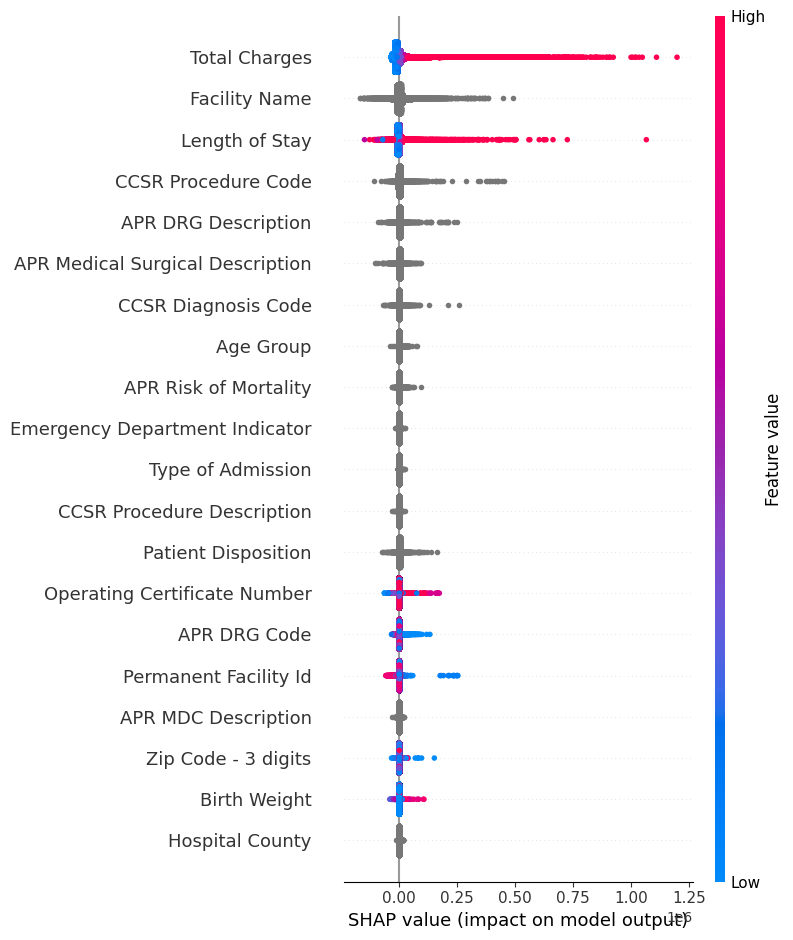

In [10]:
# Visualize feature importance
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

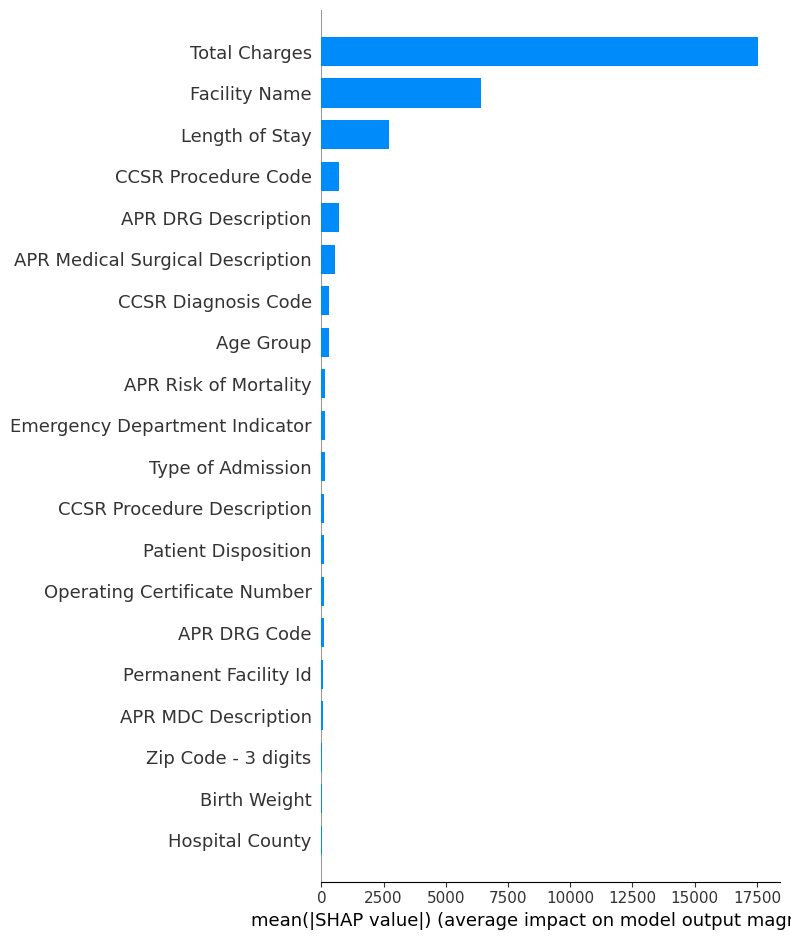

In [ ]:
features = X_test.columns.tolist()
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=features, plot_type="bar")

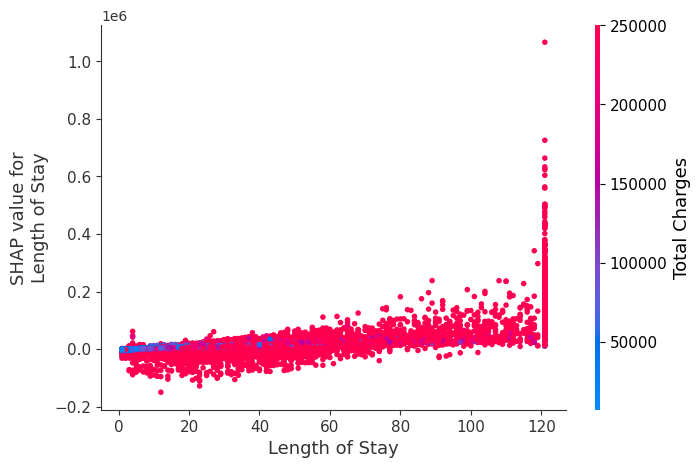

In [ ]:
feature_index = 10
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

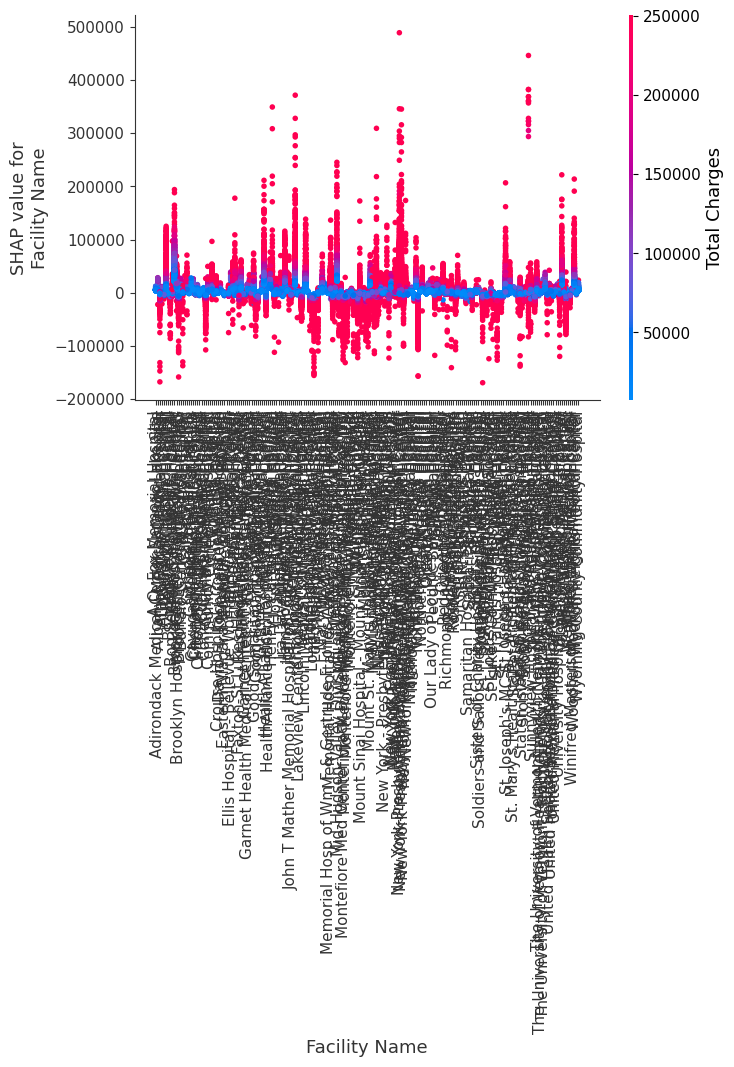

In [ ]:
feature_index = 4
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

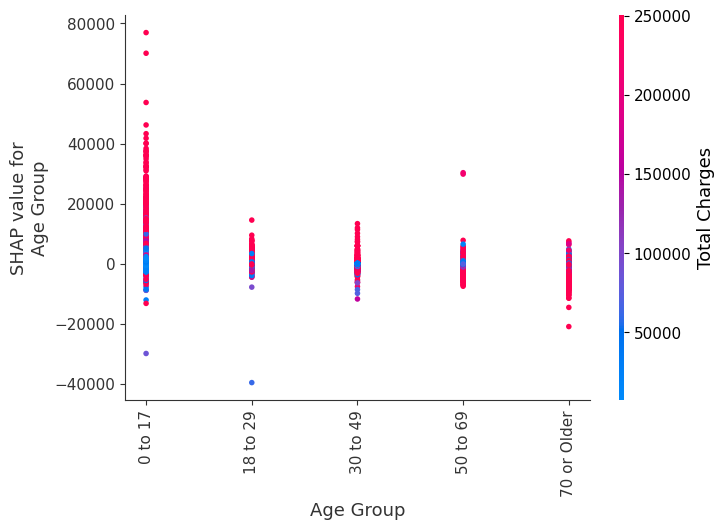

In [ ]:
feature_index = 5
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

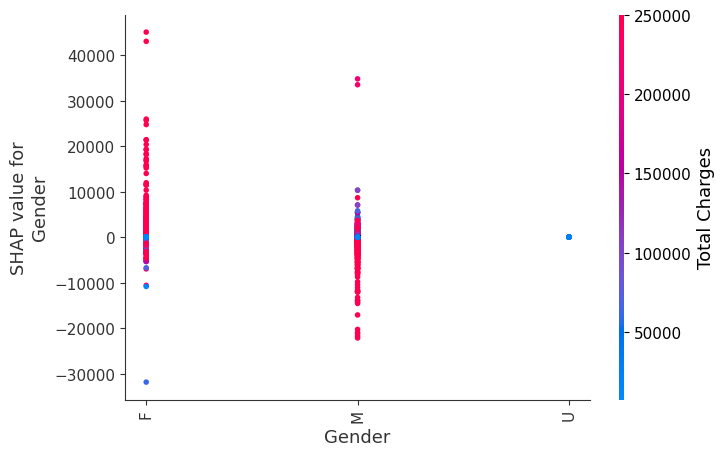

In [ ]:
feature_index = 7
shap.dependence_plot(feature_index, shap_values, X_test, feature_names=features)

In [ ]:
shap.initjs()

instance_index = 0
shap.force_plot(explainer.expected_value, shap_values[instance_index], X_test.iloc[instance_index], feature_names=features)

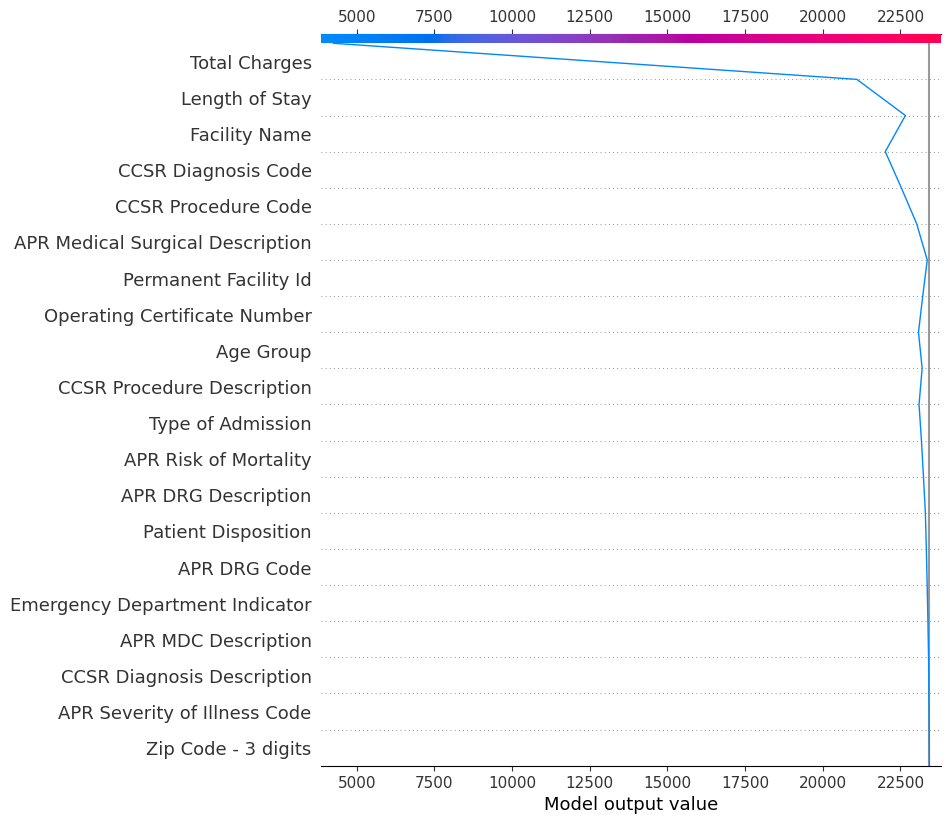

In [ ]:
shap.decision_plot(explainer.expected_value, shap_values[0], feature_names=features)

# Counterfactual Explanation

In [ ]:
import dice_ml
from sklearn.preprocessing import LabelEncoder


data_temp = data.copy()

target = 'Total Costs'
categorical_columns = [col for col in data_temp.columns if data_temp[col].dtype == "category"]
numerical_columns = [col for col in data_temp.columns if data_temp[col].dtype != "category" and col != target]

# for col in data_temp.select_dtypes(include='category').columns:
#     le = LabelEncoder()
#     data_temp[col] = le.fit_transform(data_temp[col].astype(str))

# Load data
dataset = dice_ml.Data(
    dataframe=data_temp,
    continuous_features=numerical_columns,
    categorical_features=categorical_columns,
    outcome_name=target
)

# Load model
dice_model = dice_ml.Model(model=model, backend="sklearn", model_type='regressor')

# Initialize explainer
dice_explainer = dice_ml.Dice(dataset, dice_model, method='random')

In [26]:
sample_patient_dict = data_temp.loc[[0]].drop(columns=["Total Costs"])

# Generate counterfactuals
cf = dice_explainer.generate_counterfactuals(sample_patient_dict, total_CFs=3, desired_range=[1000, 8000])

# Visualize and save
cf.visualize_as_dataframe()
print(cf.cf_examples_list[0].final_cfs_df)

  0%|          | 0/1 [00:00<?, ?it/s]


ValueError: train and valid dataset categorical_feature do not match.

# LIME

In [29]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


data_temp = data.copy()

for col in data_temp.select_dtypes(include='category').columns:
    le = LabelEncoder()
    data_temp[col] = le.fit_transform(data_temp[col].astype(str))

X = data_temp.drop(columns=['Total Costs', ])
y = data_temp['Total Costs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# LIME explainer
explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    mode='regression'
)

# test sample
query_instance = X_test.iloc[0]

# get LIME explanations
exp = explainer.explain_instance(
    data_row=query_instance.values,
    predict_fn=model.predict,
    num_features=10
)

/Users/mahsaamani/Downloads/Saarlanduni/DataScience/UnveilingHospitalCostDrivers/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [30]:
exp.show_in_notebook(show_table=True)

print("Prediction:", model.predict([query_instance.values])[0])
print("LIME Explanation:")
print(exp.as_list())

Prediction: 4241.292038287831
LIME Explanation:
[('Total Charges <= 20435.94', -41841.803781886214), ('Hospital Service Area > 5.00', 3947.5992437676196), ('Facility Name <= 66.00', 3572.2056029412024), ('APR Medical Surgical Description <= 0.00', 3512.332789763196), ('241.00 < CCSR Procedure Description <= 315.00', 3417.140720268621), ('76.00 < APR DRG Description <= 198.00', -3246.1462138872157), ('Zip Code - 3 digits > 125.00', -2819.351939344946), ('Type of Admission <= 1.00', 2560.1957646999854), ('Hospital County <= 21.00', 2128.5412381627234), ('Birth Weight <= -1.00', -2111.61894818441)]


/Users/mahsaamani/Downloads/Saarlanduni/DataScience/UnveilingHospitalCostDrivers/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
